In [1]:
import json
import pandas as pd

candidates=[]

with open("../data/candidates.jsonl","r") as f:
    for line in f:
        if line.strip():
            candidates.append(json.loads(line))

print(len(candidates))


100000


In [2]:
rows=[]

for c in candidates:

    profile = c["profile"]

    rows.append({
        "candidate_id":c["candidate_id"],
        "title":profile["current_title"],
        "experience":profile["years_of_experience"],
        "industry":profile["current_industry"],
        "company":profile["current_company"],
        "country":profile["country"]
    })

df=pd.DataFrame(rows)

df.head()

,candidate_id,title,experience,industry,company,country
0,CAND_0000001,Backend Engineer,6.9,IT Services,Mindtree,Canada
1,CAND_0000002,Operations Manager,12.5,IT Services,Wipro,India
2,CAND_0000003,Customer Support,1.1,IT Services,TCS,USA
3,CAND_0000004,Marketing Manager,3.8,Paper Products,Dunder Mifflin,Australia
4,CAND_0000005,Accountant,11.0,Manufacturing,Stark Industries,India


In [3]:
df["title"].value_counts().head(30)

title
Business Analyst            5833
HR Manager                  5830
Mechanical Engineer         5791
Accountant                  5764
Project Manager             5754
Customer Support            5750
Operations Manager          5744
Content Writer              5727
Sales Executive             5713
Civil Engineer              5702
Graphic Designer            5689
Marketing Manager           5524
Software Engineer           3450
Full Stack Developer        2873
Cloud Engineer              2836
Java Developer              2809
.NET Developer              2788
DevOps Engineer             2787
Mobile Developer            2757
Frontend Engineer           2738
QA Engineer                 2682
Analytics Engineer           764
Data Engineer                744
Data Analyst                 728
Backend Engineer             704
Senior Data Engineer         687
Senior Software Engineer     653
ML Engineer                  167
AI Research Engineer         153
Data Scientist               145
Name

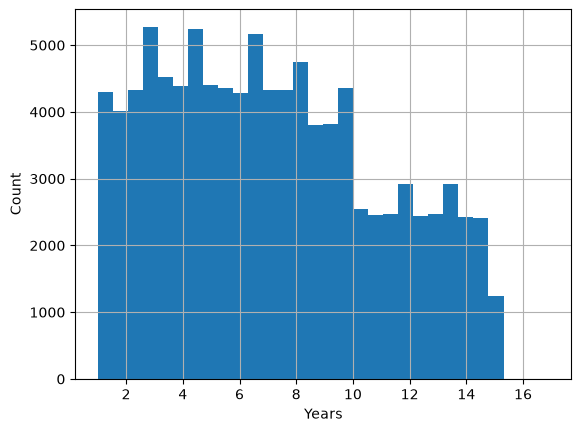

In [4]:
import matplotlib.pyplot as plt

df["experience"].hist(bins=30)

plt.xlabel("Years")
plt.ylabel("Count")
plt.show()

In [5]:
df["industry"].value_counts().head(20)

industry
IT Services          29881
Software             22417
Manufacturing        22305
Conglomerate          7571
Paper Products        7467
Fintech               2808
Food Delivery         2514
E-commerce            1529
Consulting            1274
EdTech                 610
SaaS                   328
AI/ML                  278
AdTech                 172
Transportation         162
Insurance Tech         155
Gaming                 149
HealthTech             147
HealthTech AI           68
Conversational AI       62
AI Services             42
Name: count, dtype: int64

In [6]:
skills=[]

for c in candidates:

    for s in c["skills"]:
        skills.append(s["name"])

skills_df=pd.Series(skills)

skills_df.value_counts().head(50)

HTML                  12246
Databricks            12244
Redux                 12222
Terraform             12187
Angular               12173
Figma                 12157
Salesforce CRM        12157
Vue.js                12142
Sales                 12138
Accounting            12136
Agile                 12135
Kafka                 12114
Excel                 12109
BigQuery              12108
CI/CD                 12108
Project Management    12106
Airflow               12105
AWS                   12104
Flask                 12104
Scrum                 12083
Illustrator           12072
Kubernetes            12071
ETL                   12068
CSS                   12065
Docker                12062
Next.js               12058
Apache Beam           12054
Java                  12049
Go                    12049
TypeScript            12048
JavaScript            12047
dbt                   12046
REST APIs             12040
Spark                 12038
Marketing             12037
Tally               

In [7]:
signals=[]

for c in candidates:

    r = c["redrob_signals"]

    signals.append({
        "response_rate":r["recruiter_response_rate"],
        "github_score":r["github_activity_score"],
        "saved":r["saved_by_recruiters_30d"],
        "search":r["search_appearance_30d"],
        "open_to_work":r["open_to_work_flag"]
    })

signals_df=pd.DataFrame(signals)

signals_df.describe()

,response_rate,github_score,saved,search
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.436574,9.619230,7.658700,117.543800
std,0.214122,17.761394,5.921436,92.825891
min,0.020000,-1.000000,0.000000,0.000000
25%,0.250000,-1.000000,3.000000,52.000000
50%,0.440000,-1.000000,7.000000,105.000000
75%,0.620000,16.700000,11.000000,158.000000
max,0.950000,96.900000,80.000000,1490.000000


In [8]:
ai_titles=[]

for c in candidates:

    title = c["profile"]["current_title"]

    if "AI" in title or "ML" in title or "Machine Learning" in title:
        ai_titles.append(title)

pd.Series(ai_titles).value_counts()

ML Engineer                         167
AI Research Engineer                153
Senior Software Engineer (ML)       142
Junior ML Engineer                  131
AI Specialist                       130
Machine Learning Engineer            24
Applied ML Engineer                  23
AI Engineer                          21
Senior Machine Learning Engineer      6
Staff Machine Learning Engineer       6
Senior AI Engineer                    4
Lead AI Engineer                      3
Name: count, dtype: int64

In [9]:
titles=df["title"].unique()

print(len(titles))

sorted(titles)

47


['.NET Developer',
 'AI Engineer',
 'AI Research Engineer',
 'AI Specialist',
 'Accountant',
 'Analytics Engineer',
 'Applied ML Engineer',
 'Backend Engineer',
 'Business Analyst',
 'Civil Engineer',
 'Cloud Engineer',
 'Computer Vision Engineer',
 'Content Writer',
 'Customer Support',
 'Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'DevOps Engineer',
 'Frontend Engineer',
 'Full Stack Developer',
 'Graphic Designer',
 'HR Manager',
 'Java Developer',
 'Junior ML Engineer',
 'Lead AI Engineer',
 'ML Engineer',
 'Machine Learning Engineer',
 'Marketing Manager',
 'Mechanical Engineer',
 'Mobile Developer',
 'NLP Engineer',
 'Operations Manager',
 'Project Manager',
 'QA Engineer',
 'Recommendation Systems Engineer',
 'Sales Executive',
 'Search Engineer',
 'Senior AI Engineer',
 'Senior Applied Scientist',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Senior Machine Learning Engineer',
 'Senior NLP Engineer',
 'Senior Software Engineer',
 'Senior Software Engineer (ML)',

In [10]:
ai_titles=[]

for c in candidates:

    title=c["profile"]["current_title"]

    if (
        "AI" in title
        or "ML" in title
        or "Machine Learning" in title
        or "Data Scientist" in title
        or "Applied Scientist" in title
    ):
        ai_titles.append(title)

pd.Series(ai_titles).value_counts()

ML Engineer                         167
AI Research Engineer                153
Data Scientist                      145
Senior Software Engineer (ML)       142
Junior ML Engineer                  131
AI Specialist                       130
Machine Learning Engineer            24
Applied ML Engineer                  23
AI Engineer                          21
Senior Data Scientist                19
Senior Machine Learning Engineer      6
Staff Machine Learning Engineer       6
Senior AI Engineer                    4
Senior Applied Scientist              4
Lead AI Engineer                      3
Name: count, dtype: int64

In [11]:
industries=[]

for c in candidates:
    industries.append(
        c["profile"]["current_industry"]
    )

pd.Series(industries).value_counts().head(30)

IT Services             29881
Software                22417
Manufacturing           22305
Conglomerate             7571
Paper Products           7467
Fintech                  2808
Food Delivery            2514
E-commerce               1529
Consulting               1274
EdTech                    610
SaaS                      328
AI/ML                     278
AdTech                    172
Transportation            162
Insurance Tech            155
Gaming                    149
HealthTech                147
HealthTech AI              68
Conversational AI          62
AI Services                42
Voice AI                   31
Internet                   22
Media                       6
Consumer Electronics        2
Name: count, dtype: int64

In [12]:
sizes=[]

for c in candidates:
    sizes.append(
        c["profile"]["current_company_size"]
    )

pd.Series(sizes).value_counts()

10001+        40464
1001-5000     18201
201-500       15096
51-200         7727
11-50          7568
501-1000       7525
5001-10000     3419
Name: count, dtype: int64

In [13]:
signals=[]

for c in candidates:

    r=c["redrob_signals"]

    signals.append({
        "response_rate":
        r["recruiter_response_rate"],

        "github":
        r["github_activity_score"],

        "saved":
        r["saved_by_recruiters_30d"],

        "search":
        r["search_appearance_30d"]
    })

signals_df=pd.DataFrame(signals)

signals_df.describe()

,response_rate,github,saved,search
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.436574,9.619230,7.658700,117.543800
std,0.214122,17.761394,5.921436,92.825891
min,0.020000,-1.000000,0.000000,0.000000
25%,0.250000,-1.000000,3.000000,52.000000
50%,0.440000,-1.000000,7.000000,105.000000
75%,0.620000,16.700000,11.000000,158.000000
max,0.950000,96.900000,80.000000,1490.000000


In [14]:
ai_skills=[]

keywords=[
"Python",
"PyTorch",
"TensorFlow",
"Transformers",
"LLM",
"LangChain",
"RAG",
"OpenAI",
"Pinecone",
"Qdrant",
"FAISS",
"Elasticsearch"
]

for c in candidates:

    for skill in c["skills"]:

        if skill["name"] in keywords:
            ai_skills.append(skill["name"])

pd.Series(ai_skills).value_counts()

LangChain        5162
Pinecone         5062
FAISS            5052
RAG              4995
TensorFlow       1381
Qdrant           1379
Python           1378
PyTorch          1378
Elasticsearch    1311
Name: count, dtype: int64

In [15]:
title_weights = {

    "Senior AI Engineer":10,
    "Staff Machine Learning Engineer":10,
    "Senior Machine Learning Engineer":10,
    "Lead AI Engineer":9,
    "AI Research Engineer":9,
    "ML Engineer":8,
    "Machine Learning Engineer":8,
    "Applied ML Engineer":8,
    "Data Scientist":6,
    "Senior Data Scientist":7,
    "AI Specialist":6,
    "Junior ML Engineer":4
}

In [16]:
def experience_score(exp):

    if 5<=exp<=9:
        return 1

    elif 4<=exp<=12:
        return .8

    else:
        return .4

In [17]:
core_ai_skills = {

"Python",
"PyTorch",
"TensorFlow",
"Transformers",
"LLM",
"RAG",
"Pinecone",
"Qdrant",
"FAISS",
"Elasticsearch",
"OpenAI",
"Embeddings"
}

In [19]:
job_counts=[]

for c in candidates:
    job_counts.append(len(c["career_history"]))

pd.Series(job_counts).describe()

count    100000.000000
mean          3.001710
std           1.522442
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           9.000000
dtype: float64

In [20]:
durations=[]

for c in candidates:

    months=0

    for job in c["career_history"]:
        months += job["duration_months"]

    durations.append(months)

pd.Series(durations).describe()

count    100000.000000
mean         84.756970
std          45.340071
min           8.000000
25%          46.000000
50%          81.000000
75%         118.000000
max         365.000000
dtype: float64

In [21]:
ai_candidates=[]

for c in candidates:

    title = c["profile"]["current_title"]

    if (
        "AI" in title
        or "ML" in title
        or "Machine Learning" in title
        or "Data Scientist" in title
    ):
        ai_candidates.append(c)

print(len(ai_candidates))

974
